# §4 Individual with ML#2 filter (v11) — net of costs

Per-combo metrics and equity/drawdown curves after applying the V3
booster + pooled-R:R isotonic calibrator filter.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick). Applied to both sizing policies.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v11.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v11.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 14,717


Loaded combos_ml2 from cache (10 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 568, 'pct5_compound': 568}


In [2]:
rows = []
for cid, entry in s4_pnl_by_combo.items():
    pnl_base = entry['pnl_base']; risk_base = entry['risk_base']
    if len(pnl_base) == 0:
        for policy in POLICIES:
            rows.append({'combo_id': cid, 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = entry['by_policy'][policy]
        rows.append({'combo_id': cid, 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf4 = pd.DataFrame(rows)
perf4

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_7877,fixed_dollars_500,22,15.1,0.2273,726.40,1.45,0.1739,7.52,3919.14
1,v10_7877,pct5_compound,22,15.1,0.2273,-192.87,-0.39,-0.0068,44.06,28732.61
2,v10_7716,fixed_dollars_500,34,23.3,0.0882,-4258.18,-8.52,-0.9598,12.01,6038.74
3,v10_7716,pct5_compound,34,23.3,0.0882,-20560.93,-41.12,-1.1786,48.53,24519.31
4,v10_9017,fixed_dollars_500,90,61.6,0.1889,2553.26,5.11,0.4038,6.06,3072.89
5,v10_9017,pct5_compound,90,61.6,0.1889,6147.89,12.30,0.1467,34.84,18947.16
6,v10_3616,fixed_dollars_500,132,90.3,0.2879,-2679.59,-5.36,-0.3521,15.00,8017.98
7,v10_3616,pct5_compound,132,90.3,0.2879,-26566.65,-53.13,-0.7278,73.44,54660.34
8,v10_7872,fixed_dollars_500,2,1.4,0.0000,-375.65,-0.75,-0.8738,0.75,375.65
9,v10_7872,pct5_compound,2,1.4,0.0000,-2636.97,-5.27,-0.8726,5.27,2636.97


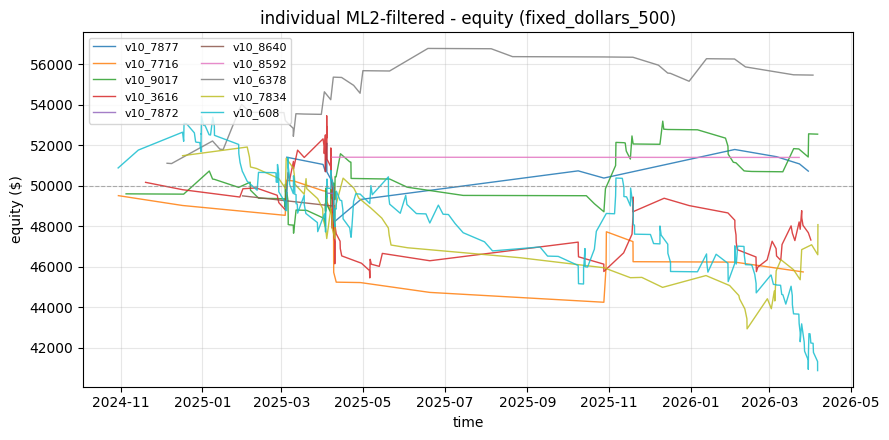

In [3]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'fixed_dollars_500')

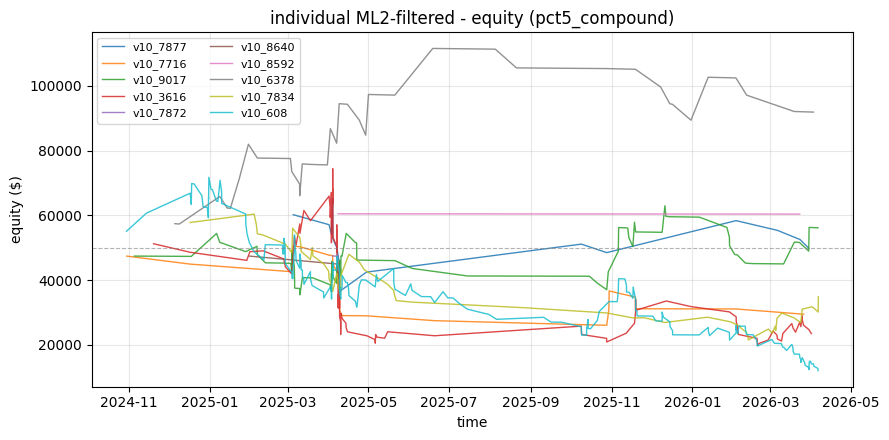

In [4]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'pct5_compound')

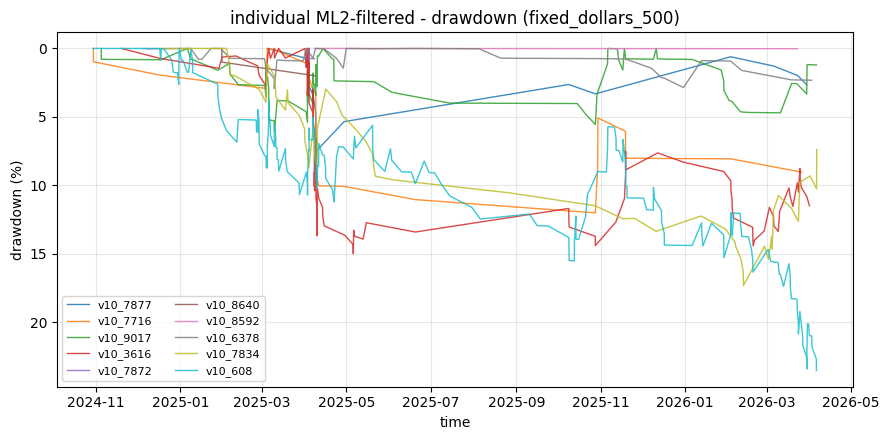

In [5]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'fixed_dollars_500')

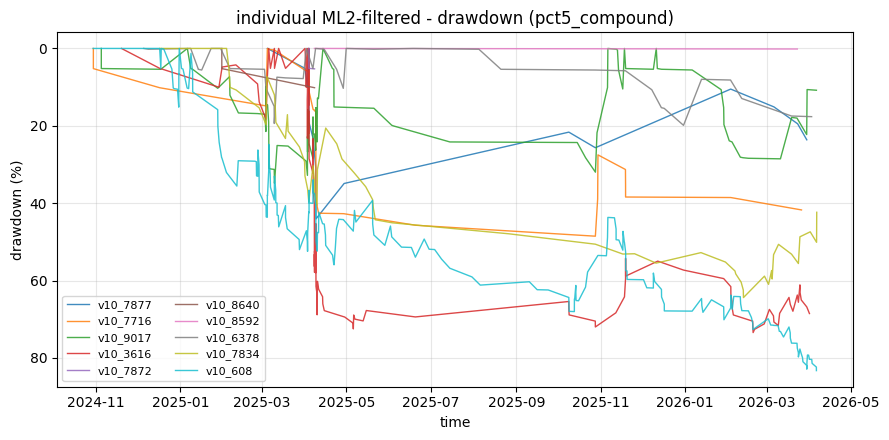

In [6]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'pct5_compound')